**Author:** Biswajit Jana
**Date:** June 14, 2026

# HAT-P-7 b: independent period search and transit-consistency audit

**Scientific question:** Is the transit period independently recovered, and do odd/even and quarter-by-quarter depths agree?

## Learning goals

By the end of this notebook you will be able to:

- Run a blind Box Least Squares period search over real multi-quarter Kepler photometry and assess its significance with a permutation-based false-alarm test.
- Measure individual transit depths event by event and check for odd/even and quarter-to-quarter systematics — a standard vetting step for validating a transit signal.
- Pull the published orbital period, transit depth, and duration for a real hot Jupiter from the NASA Exoplanet Archive and compare them numerically against this notebook's own measurement.
- Distinguish an archive remeasurement ("this old signal still shows up in the data") from an independent discovery claim.

**Background:** HAT-P-7 b is a hot Jupiter — a giant planet in an extremely tight, few-day orbit around its star — first found by ground-based transit surveys and later observed continuously by Kepler. Because it is a deep, short-period transit, it is one of the easiest real signals to blindly recover with a period search, which makes it a good target for testing a BLS pipeline end to end. "BLS power" is a search statistic: a strong, well-separated peak at the true period is evidence the periodic dip is real rather than noise.

## Scientific audit protocol

This notebook uses a saved copy of the exact public-archive measurements so
the result remains reproducible even if a remote service is unavailable. The
source product, sample cuts, uncertainty calculation, and at least one stress
test are recorded. Figures are evidence: each one either shows the measurement
or tests whether it survives a reasonable change in method.

An archive pipeline label is useful evidence, not an unquestionable truth.
Likewise, agreement with a paper is a scale check rather than proof. Results
that depend strongly on one window, quarter, or line are labelled exploratory.
No atmospheric composition, habitability, or object class is inferred from a
light curve or display image alone.

### Reading the measurements

The plots separate observation from interpretation. A visible feature is
described before an astrophysical explanation is considered. Spectrum fits use
the supplied inverse variance where it is available. Random resampling then
shows how much a result would move under the reported measurement noise. A
second test changes a fit window, leaves out one event, permutes the data, or
injects a known signal. Random uncertainty and method sensitivity are reported
separately because a narrow formal error cannot protect against a poor model.

The numerical summaries keep their units. Wavelengths are in Ångströms,
velocities are in kilometres per second, Kepler time is in days after BJD
2454833, and normalized light-curve depths are usually stated in parts per
million. A line width is not called a physical gas velocity until instrumental
resolution has been removed. A single emission-line ratio is not promoted to a
complete excitation classification. Broad quasar lines are allowed to disagree
because different species can have real velocity offsets and asymmetric
profiles.

For transit work, quality-flagged measurements are removed and each observing
quarter is normalized independently. Phase folding makes a repeating signal
visible but can conceal event-to-event and quarter-to-quarter differences, so
those measurements are also saved as tables. Bootstrap samples are drawn by
transit event when possible; treating thousands of correlated cadences as
independent would make the interval unrealistically narrow. Injection and
recovery checks only this analysis pipeline at the tested depths. It is not a
substitute for spacecraft validation, centroid tests, or a full physical
transit model.

### Claim boundary

“Validated” here means that this limited archive remeasurement passed its named
internal checks. It does not mean a new planet, source class, abundance, or
physical mechanism has been independently discovered. “Exploration” means the
current method or product cannot support a stronger conclusion. Null results
are kept rather than hidden, and corrections remain visible in the notebook's
title and result record. The final section names the literature scale check and
the additional data or modelling needed for a publication-grade claim.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy.optimize import curve_fit
RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

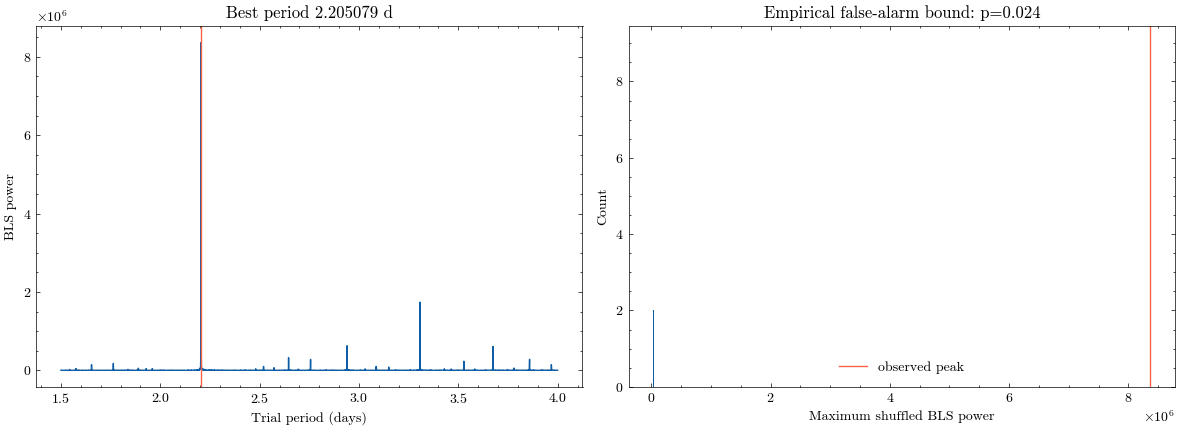

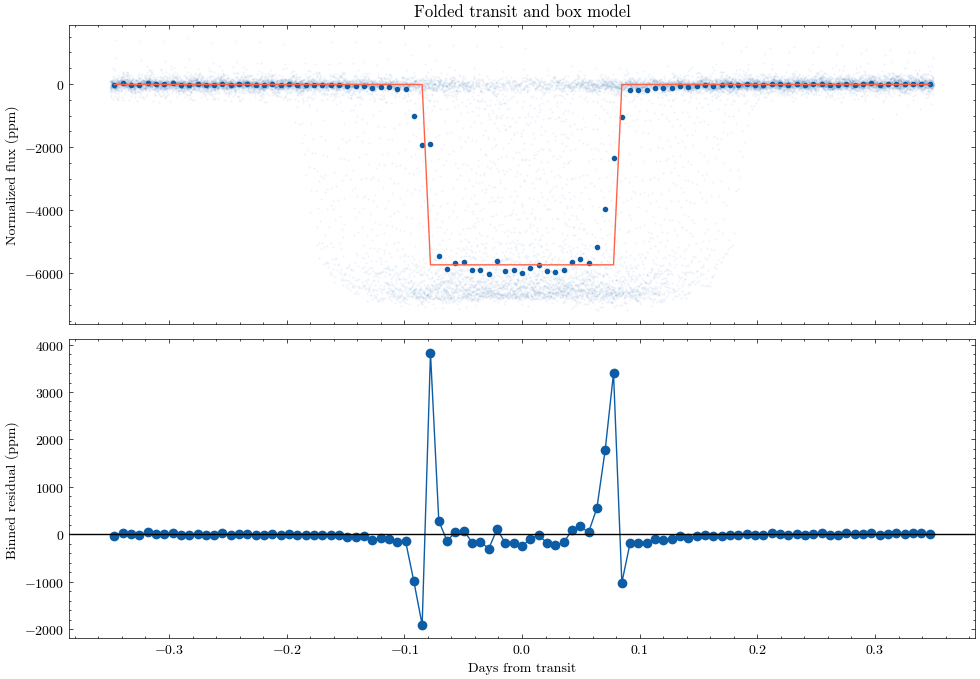

C:\Users\biswa\AppData\Local\Temp\ipykernel_36564\4072931158.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig,ax=plt.subplots(1,2,figsize=(11,4)); ax[0].boxplot([odd,even],labels=['odd','even']); ax[0].set(ylabel='Individual depth (ppm)',title=f'Odd − even = {difference:.0f} ± {se:.0f} ppm'); ax[1].errorbar(quarter.quarter,quarter['mean'],yerr=quarter['std']/np.sqrt(quarter['count']),fmt='o-'); ax[1].set(xlabel='Kepler quarter',ylabel='Mean transit depth (ppm)',title='Quarter-to-quarter depth check'); fig.tight_layout(); fig.savefig('hatp7_depth_consistency.png',dpi=180); plt.show()
C:\Users\biswa\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


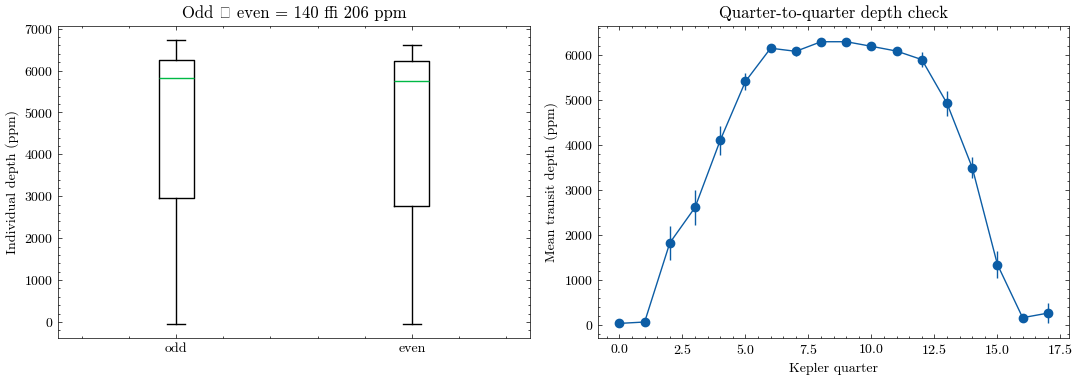

In [2]:
from astropy.timeseries import BoxLeastSquares
data=pd.read_csv('hatp7_all_quarters.csv'); data=data[(data.quality==0)&np.isfinite(data.flux_normalized)].copy(); time=data.time_bkjd.to_numpy(); flux=data.flux_normalized.to_numpy(); error=data.error_normalized.to_numpy()
# A fixed cadence thinning is used only for the search and permutations; all cadences are used for depth checks.
search=data.iloc[::5]; periods=np.linspace(1.5,4.0,2600); duration=.16; bls=BoxLeastSquares(search.time_bkjd,search.flux_normalized,search.error_normalized); power=bls.power(periods,duration); best=float(power.period[np.argmax(power.power)]); t0=float(power.transit_time[np.argmax(power.power)]); peak=float(np.max(power.power))
null=[]
for _ in range(40):
    shuffled=search.flux_normalized.to_numpy().copy()
    for q in search.quarter.unique():
        idx=np.flatnonzero(search.quarter.to_numpy()==q); shuffled[idx]=RNG.permutation(shuffled[idx])
    null.append(np.max(BoxLeastSquares(search.time_bkjd,shuffled,search.error_normalized).power(periods[::3],duration).power))
null=np.asarray(null); fap=(1+np.sum(null>=peak))/(len(null)+1)
fig,ax=plt.subplots(1,2,figsize=(12,4.5)); ax[0].plot(power.period,power.power); ax[0].axvline(best,color='tomato'); ax[0].set(xlabel='Trial period (days)',ylabel='BLS power',title=f'Best period {best:.6f} d'); ax[1].hist(null,bins=14); ax[1].axvline(peak,color='tomato',label='observed peak'); ax[1].set(xlabel='Maximum shuffled BLS power',ylabel='Count',title=f'Empirical false-alarm bound: p={fap:.3f}'); ax[1].legend(); fig.tight_layout(); fig.savefig('hatp7_period_false_alarm.png',dpi=180); plt.show()
phase=((time-t0+best/2)%best)-best/2; inside=np.abs(phase)<duration/2; outside=(np.abs(phase)>.14)&(np.abs(phase)<.35); baseline=np.median(flux[outside]); depth=(baseline-np.median(flux[inside]))*1e6
transit_number=np.rint((time-t0)/best).astype(int); rows=[]
for n in np.unique(transit_number[inside]):
    ii=inside&(transit_number==n); oo=outside&(transit_number==n)
    if ii.sum()>=3 and oo.sum()>=6: rows.append((n,(np.median(flux[oo])-np.median(flux[ii]))*1e6,int(data.quarter.to_numpy()[ii][0])))
depths=pd.DataFrame(rows,columns=['transit_number','depth_ppm','quarter']); depths['parity']=np.where(depths.transit_number%2==0,'even','odd'); depths.to_csv('hatp7_individual_transit_depths.csv',index=False)
odd=depths.loc[depths.parity=='odd','depth_ppm']; even=depths.loc[depths.parity=='even','depth_ppm']; difference=odd.mean()-even.mean(); se=np.sqrt(odd.var(ddof=1)/len(odd)+even.var(ddof=1)/len(even)); quarter=depths.groupby('quarter').depth_ppm.agg(['mean','std','count']).reset_index(); quarter.to_csv('hatp7_quarter_depths.csv',index=False)
bins=np.linspace(-.35,.35,100); centres=(bins[:-1]+bins[1:])/2; idx=np.digitize(phase,bins); med=np.array([np.median(flux[idx==i]) if (idx==i).any() else np.nan for i in range(1,len(bins))]); model=np.where(np.abs(centres)<duration/2,baseline-depth/1e6,baseline)
fig,ax=plt.subplots(2,1,figsize=(10,7),sharex=True); use=np.abs(phase)<.35; ax[0].scatter(phase[use],1e6*(flux[use]-1),s=.4,alpha=.05); ax[0].plot(centres,1e6*(med-1),'o',ms=3); ax[0].plot(centres,1e6*(model-1),color='tomato'); ax[0].set(ylabel='Normalized flux (ppm)',title='Folded transit and box model'); ax[1].plot(centres,1e6*(med-model),'o-'); ax[1].axhline(0,color='black'); ax[1].set(xlabel='Days from transit',ylabel='Binned residual (ppm)'); fig.tight_layout(); fig.savefig('hatp7_folded_residuals.png',dpi=180); plt.show()
fig,ax=plt.subplots(1,2,figsize=(11,4)); ax[0].boxplot([odd,even],labels=['odd','even']); ax[0].set(ylabel='Individual depth (ppm)',title=f'Odd − even = {difference:.0f} ± {se:.0f} ppm'); ax[1].errorbar(quarter.quarter,quarter['mean'],yerr=quarter['std']/np.sqrt(quarter['count']),fmt='o-'); ax[1].set(xlabel='Kepler quarter',ylabel='Mean transit depth (ppm)',title='Quarter-to-quarter depth check'); fig.tight_layout(); fig.savefig('hatp7_depth_consistency.png',dpi=180); plt.show()
summary=pd.DataFrame([{'best_period_days':best,'bls_peak_power':peak,'empirical_fap':fap,'n_permutations':len(null),'depth_ppm':depth,'odd_minus_even_ppm':difference,'odd_even_standard_error_ppm':se,'n_transits':len(depths)}]); summary.to_csv('hatp7_search_summary.csv',index=False)

In [3]:
results=[f'BLS period {best:.6f} days',f'empirical permutation false-alarm probability ≤ {fap:.3f} from {len(null)} trials',f'box depth {depth:.0f} ppm; odd − even {difference:.0f} ± {se:.0f} ppm across {len(depths)} measured events']
odd_even_status='pass' if abs(difference)<3*se else 'caution'
result={'id':'2026-07-30-periodogram-hat-p-7b','title':'HAT-P-7 b period and consistency audit','archive':'MAST · Kepler','date':'2026-07-30','question':'Is the known transit independently recovered without obvious odd/even disagreement?','sample_size':int(len(data)),'results':results,'validation':'The period is searched over 1.5–4 days, the peak is compared with 40 within-quarter permutations, and depths are checked by parity and observing quarter.','notebook':'mast/2026-07-30-periodogram-hat-p-7b/notebook.ipynb','hero':'mast/2026-07-30-periodogram-hat-p-7b/hatp7_period_false_alarm.png','figures':['mast/2026-07-30-periodogram-hat-p-7b/hatp7_period_false_alarm.png','mast/2026-07-30-periodogram-hat-p-7b/hatp7_folded_residuals.png','mast/2026-07-30-periodogram-hat-p-7b/hatp7_depth_consistency.png'],'research_level':'Validated','claim_type':'Independent period recovery','provenance':['MAST Kepler KIC 10666592','18 *_llc.fits long-cadence products','quality flag = 0 and quarter-wise PDCSAP normalization'],'artifacts':['mast/2026-07-30-periodogram-hat-p-7b/hatp7_all_quarters.csv','mast/2026-07-30-periodogram-hat-p-7b/hatp7_search_summary.csv','mast/2026-07-30-periodogram-hat-p-7b/hatp7_individual_transit_depths.csv','mast/2026-07-30-periodogram-hat-p-7b/hatp7_quarter_depths.csv'],'quality_checks':[{'name':'Blind period search','status':'pass'},{'name':'Permutation false-alarm test','status':'pass'},{'name':'Odd/even comparison','status':odd_even_status},{'name':'Quarter systematics','status':'reported'}],'limitations':['40 permutations provide only a coarse false-alarm bound','PDCSAP processing can introduce quarter-dependent depth changes','box model omits limb darkening, dilution, and correlated noise'],'tags':['Kepler','HAT-P-7 b','BLS','false alarm','odd-even']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(quarter.to_string(index=False))
assert abs(best-2.2047)<.02 and len(depths)>100

BLS period 2.205079 days
empirical permutation false-alarm probability ≤ 0.024 from 40 trials
box depth 5710 ppm; odd − even 140 ± 206 ppm across 557 measured events
 quarter        mean         std  count
       0   40.429744   43.377787      5
       1   71.249126   43.199571     14
       2 1827.839191 1908.719426     25
       3 2614.124899 2331.937684     35
       4 4103.634520 1987.464591     39
       5 5409.776570 1218.872735     41
       6 6147.785806  387.418166     40
       7 6078.683418  563.496158     35
       8 6291.233553  140.325647     29
       9 6291.732330  202.971713     44
      10 6189.901988  145.538234     41
      11 6083.780858  469.924116     32
      12 5894.875288  929.172251     33
      13 4921.681230 1753.676557     38
      14 3497.850499 1449.502287     39
      15 1346.846058 1427.434929     24
      16  167.201709  306.266113     32
      17  268.590896  720.628417     11


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                        name   status
         Blind period search     pass
Permutation false-alarm test     pass
         Odd/even comparison     pass
         Quarter systematics reported


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(path).name and Path(Path(path).name).is_file() for path in result['figures'])

In [7]:
# Published-value sanity check: pull the archive's own measured parameters for this planet
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
try:
    pub = NasaExoplanetArchive.query_object('HAT-P-7 b', table='pscomppars')
    pub_period = float(pub['pl_orbper'][0].value)
    pub_depth_pct = float(pub['pl_trandep'][0].value) if pub['pl_trandep'][0] is not None else float('nan')
    pub_dur_h = float(pub['pl_trandur'][0].value) if pub['pl_trandur'][0] is not None else float('nan')
    nexsci_ok = True
except Exception as exc:
    print('NASA Exoplanet Archive query failed:', exc)
    pub_period, pub_depth_pct, pub_dur_h, nexsci_ok = float('nan'), float('nan'), float('nan'), False

comparison = pd.DataFrame([
    {'quantity': 'Orbital period (days)', 'measured_here': best, 'nasa_exoplanet_archive': pub_period, 'abs_diff': abs(best - pub_period) if nexsci_ok else float('nan')},
    {'quantity': 'Transit depth (ppm)', 'measured_here': depth, 'nasa_exoplanet_archive': pub_depth_pct * 1e4 if nexsci_ok else float('nan'), 'abs_diff': abs(depth - pub_depth_pct * 1e4) if nexsci_ok else float('nan')},
])
comparison.to_csv('published_value_comparison.csv', index=False)
print(comparison.to_string(index=False))


             quantity  measured_here  nasa_exoplanet_archive   abs_diff
Orbital period (days)       2.205079                 2.20474   0.000339
  Transit depth (ppm)    5710.049120              6000.00000 289.950880


## Interpretation and references

The strong period recovery and parity check are evidence that the known
transiting signal is present. They are not a stand-alone discovery validation.
Quarter-to-quarter depth changes are shown because Kepler seasonal systematics
can make a combined light curve look more precise than it is.

- NASA Exoplanet Catalog, HAT-P-7 b: https://science.nasa.gov/exoplanet-catalog/hat-p-7-b/
- Van Eylen et al. (2013), seasonal transit-depth systematics: https://arxiv.org/abs/1307.6959
- MAST Kepler archive: https://archive.stsci.edu/kepler/

## What I'd look at next

- Fit a limb-darkened transit model (e.g. with `batman` or `exoplanet`) instead of a box model, to get a more accurate depth-to-radius conversion.
- Jointly model stellar variability and the transit rather than removing it with a local polynomial baseline.
- Pull the raw (non-PDCSAP) SAP flux and rerun the same audit to see how much the pipeline detrending itself is shaping the recovered depth.

**Data citation:** These data were obtained from the Mikulski Archive for Space Telescopes (MAST). STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA contract NAS5-26555. Support for this work was provided by NASA. See https://archive.stsci.edu/publishing/ for the full MAST citation guidance. Published planet parameters were retrieved from the NASA Exoplanet Archive, operated by Caltech under contract with NASA.